In [1]:
using LinearAlgebra
using QuantumToolbox
using CairoMakie

# Main Functions

In [8]:
const Sub_divisions = 64
const iterations = 1024
const time = 400
const tolerance = 0.998
const step_size = 5

initial_state = ComplexF64[1;0]
H_Gate = ComplexF64[1/√2 1/√2; 1/√2 -1/√2]
T_gate = ComplexF64[1 0; 0 exp(im*π/Sub_divisions)]

function apply_gate(state, gate)
    return gate * state
end

function rotate(state, t)
    return T_gate ^ t * state
end

function measure(vec)
    if abs2(vec[1]) > rand()
        vec[1] = 1
        vec[2] = 0
        return 0
        end
    vec[1] = 0
    vec[2] = 1
    return 1
end

function ramsey(state, gate, t)
    prep = apply_gate(state, gate)
    spinning = rotate(prep, t)
    final = apply_gate(spinning, gate)
    return measure(final)
end

function count(n, state, gate, t)
    count = 0
    for i in range(1,n)
        measured = ramsey(state, gate, t)
        if measured < 1
            count += 1
        end
    end
    return count
end

function operate(t)
    t_range = range(1, t)
    data = []
    for i in t_range
        push!(data, count(iterations, initial_state, H_Gate, i))
    end
    return data
end


function convert_to_prob(lst)
    prob = []
    for i in range(1,length(lst))
        push!(prob, lst[i]/iterations)
    end
    return prob
end

convert_to_prob (generic function with 1 method)

# Plotting the Ramsey Experiment 

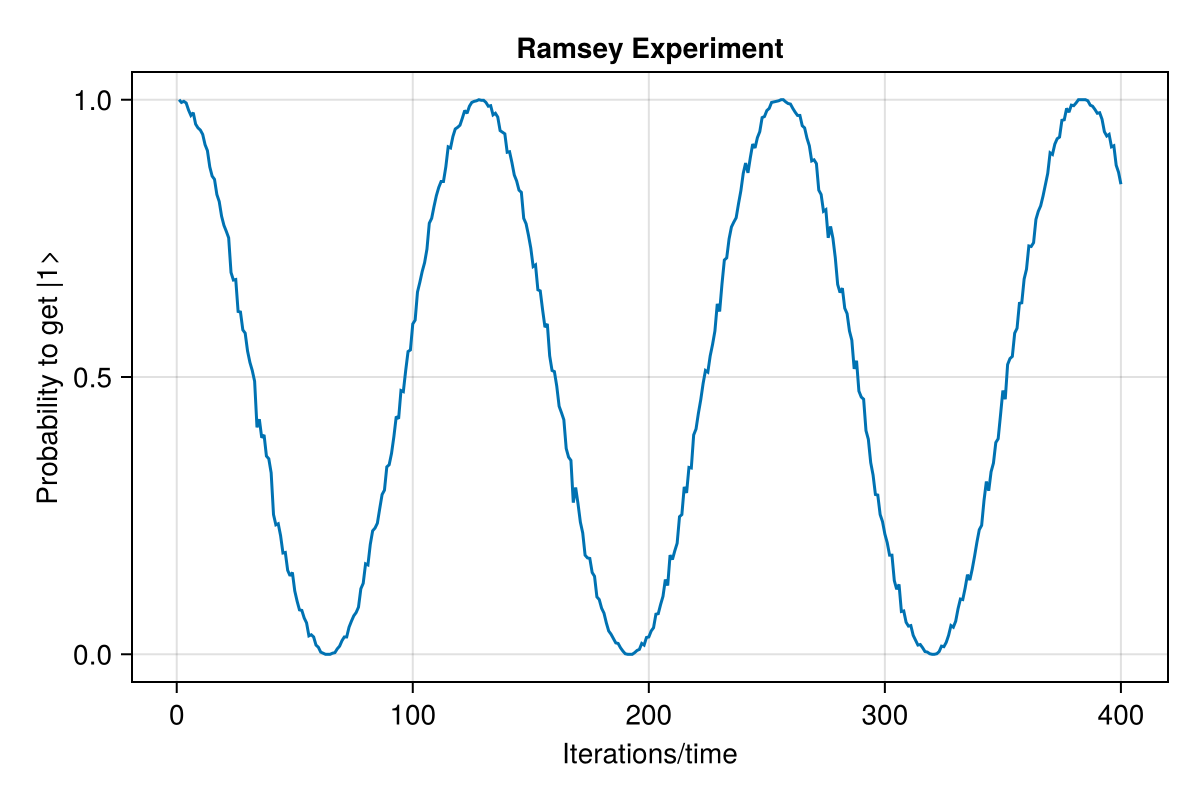

CairoMakie.Screen{IMAGE}


In [24]:
probs = convert_to_prob(operate(time))

fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Iterations/time", ylabel = "Probability to get |1>")
lines!(ax, probs)
display(fig)


# Calculating Period

In [4]:
function calculate_ramsey_period(lst, tol)
    period = []
    for i in range(1,length(lst); step = step_size)
        if lst[i]>tol
            push!(period, i)
        end
    end
    return (period[length(period)] - period[1])/length(period)
end


function calc_multi_period(time, tol)
    periods = []
    for i in range(1,10)
        push!(periods, calculate_ramsey_period(convert_to_prob(operate(time)), tolerance))
    end
    return [periods, maximum(periods), sum(periods)/length(periods)]
end

function convert_to_freq(time, tol)
    return 1/(calc_multi_period(time, tol)[2])
end

# function calc_delta(lst, tol)
#     period = []
#     for i in range(1,length(lst); step = step_size)
#         if lst[i]< (1- tol)
#             push!(period, i)
#         end
#     end
#     return [minimum(period), period]
# end


convert_to_freq (generic function with 1 method)

In [22]:
A = 0.5
C = 0.5
T1 = 150 * 10
T2 = 100 * 10
T2x = (1/2T1 + 1/T2)^-1
Δ = 2π * convert_to_freq(time, tolerance)
function P(t, A, C)
    return A * exp(-t/T2x) * cos(Δ  * t) + C
end

time_decay = 1000
decaying = []
border = []
t_range = range(1, time_decay)
for i in t_range
    push!(decaying, P(i, A, C))
    push!(border, A * exp(-i/T2x) + C)
end



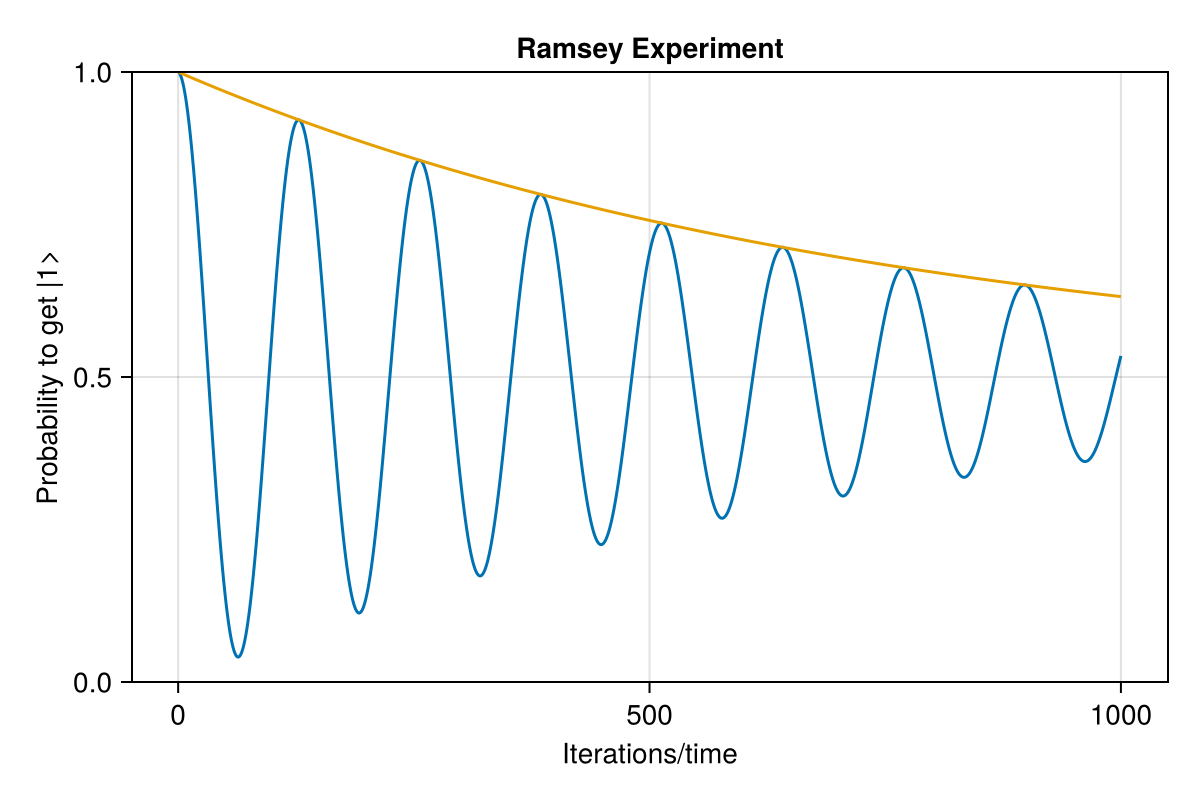

CairoMakie.Screen{IMAGE}


In [25]:
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Iterations/time", ylabel = "Probability to get |1>")
lines!(ax, decaying)
lines!(ax, border)
ylims!(ax, (0.0, 1.0))
display(fig)